In [1]:
import os
import re
import pickle as pkl
import ast
from collections import Counter
from typing import List, Tuple, Any
from tqdm import tqdm
import time

import pandas as pd
import numpy as np
import calibration as cal

import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss, roc_auc_score

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
pal = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [2]:
from llm_unsupervised_conf.metrics import *
from llm_unsupervised_conf.math_utils import stack_embeddings
from llm_unsupervised_conf.calibration import fit_predict_prob_models
from llm_unsupervised_conf.utils import maybe_add_verbal_conf_row, load_out_df, set_seed
from llm_unsupervised_conf.plots import plot_reliability, plot_avg_and_worstcase_by_method, plot_method_comparisons_by_dataset, METHODS_MAP

In [3]:
def selective_acc_at_abstention(scores, correct, abstention_rates):
    """
    scores: uncertainty scores (higher = more uncertain; abstain on largest)
    correct: {0,1} or bool
    abstention_rates: list of floats in [0,1]
    returns: np.array of selective accuracies (np.nan if keep=0)
    """
    scores = np.asarray(scores)
    correct = np.asarray(correct).astype(float)

    idx = np.argsort(-scores)          # keep lowest-uncertainty first
    correct_sorted = correct[idx]
    scores_sorted = scores[idx]
    n = len(correct_sorted)

    accs = []
    for a in abstention_rates:
        k = int(np.floor((1.0 - a) * n))   # number to keep
        if k <= 0:
            accs.append([a, np.nan, np.nan, np.nan, np.nan])
        else:
            sa = float(np.mean(correct_sorted[:k]))
            
            if a == 0.0:
                
                rc = 0.0
                ra = 0.0

                sc = 0.0
                # sa = 0.0
            else:
                
                rc = float(np.mean(scores_sorted[k:]))
                ra = float(np.mean(correct_sorted[k:]))

                sc = float(np.mean(scores_sorted[:k]))
                # sa = float(np.mean(correct_sorted[:k]))
                
            accs.append([a, sa, sc, rc, ra])
    return pd.DataFrame(accs, columns=["rate", "sel_acc", "sel_conf", "rej_conf", "rej_acc"])


In [4]:
def run_exp(
    dataset,
    model,
    n=1000,
    k_train=100,
    temp_train=0.7,
    temp_test=0.6,
    prob_models = ["ridge_clip","split_isotonic_on_ridge","split_isotonic_on_ridge_nrt"],
    include_verbal_conf=True,
    random_state=42,
    n_bins=12,
    embedding_text="question_response",
    eval_points=[0.0, 0.05, 0.1, 0.15, 0.2],
    include_ablation=True
):
    """
    prob_models controls which embedding->prob models to include.
    Example:
      prob_models=["ridge_clip","ridge_logit","hgb_logit","mlp_logit","isotonic_on_ridge"]
    """

    set_seed(random_state)

    model_name = model.split("/")[-1]

    try:
        out_df, df_save_path = load_out_df(dataset, model_name, n, temp_train, k_train, temp_test, embedding_text, drop_bad_rows=True)
    except:
        return None

    if include_ablation:
        ablation_df, _ = load_out_df(dataset, model_name, n, temp_train, k_train, temp_test, embedding_text="question", drop_bad_rows=True)
        out_df["question_embeddings"] = ablation_df["embeddings"]
        
    # --------------------
    # Split
    # --------------------
    train_df, test_df = train_test_split(
        out_df,
        test_size=0.6,
        random_state=random_state,
        shuffle=True,
    )

    X_train = stack_embeddings(train_df, "embeddings")
    y_train = train_df["consistency"].astype(np.float32).to_numpy()  # target in [0,1]

    X_test = stack_embeddings(test_df, "embeddings")

    token_counts = np.array(test_df["num_output_tokens"].tolist())

    # These are for evaluation (your core metrics are vs correctness)
    con_scores = test_df["consistency"].to_numpy(dtype=float)
    correct = test_df["correct"].to_numpy(dtype=int)

    logprobs = test_df["avg_logprobs"].to_numpy(dtype=float)
    ans_logprobs = test_df["ans_logprobs"].to_numpy(dtype=float)
    lp = np.exp(logprobs)
    alp = np.exp(ans_logprobs)

    # print(f"Results: (accuracy={correct.mean():.4f})")

    # --------------------
    # Embedding->prob models
    # --------------------
    prob_models = list(prob_models) if prob_models is not None else []
    preds = fit_predict_prob_models(
        X_train=X_train,
        y_train_prob=y_train,
        X_test=X_test,
        methods=prob_models,
        random_state=random_state,
    )
    # pred_probs = preds[prob_models[0]]

    # --------------------
    # Optional: verbal confidence
    # --------------------
    vc_scores = None
    if include_verbal_conf:
        _, vc_scores = maybe_add_verbal_conf_row([], df_save_path, test_df, correct, stem_idx=6)

    if include_ablation:
        X_train = stack_embeddings(train_df, "question_embeddings")
        X_test = stack_embeddings(test_df, "question_embeddings")
        abl_preds = fit_predict_prob_models(
            X_train=X_train,
            y_train_prob=y_train,
            X_test=X_test,
            methods=prob_models,
            random_state=random_state,
        )
        abl_probs = abl_preds[prob_models[0]]
        

    model_name = model.split("/")[-1].replace("-", "_")
    acc = np.mean(correct)

    # print("model name", model_name)
    # print("dataset", dataset)
    # print("accuracy", acc)

    scorers = [
        ["vc", vc_scores],
        ["logprob", lp],
        ["ans_logprob", alp],
        ["ridge_clip", preds["ridge_clip"]],
        ["split_isotonic_on_ridge", preds["split_isotonic_on_ridge"]],
        ["split_isotonic_on_ridge_nrt", preds["split_isotonic_on_ridge_nrt"]],
    ]

    if include_ablation:
        scorers.append(["ablation", abl_probs])

    full_df = []
    for score_name, score_vector in scorers:

        df = selective_acc_at_abstention(
            scores=score_vector,
            correct=correct,
            abstention_rates=eval_points,
        )

        df["method"] = score_name
        df["dataset"] = dataset
        df["model"] = model
        df["full_acc"] = acc
        df["sel_imp"] = (df["sel_acc"]-acc)/acc


        full_df.append(df)

    full_df = pd.concat(full_df)
    return full_df

    
        


In [5]:
def run_all_exps(models, datasets, eval_points, n_trials=1, plot_title="", figsize=(13, 6)):

    full_df = []
    for dataset in datasets:
        print(f"[status] running {dataset}")
        for model in models:
            for seed in range(n_trials):
                df = run_exp(
                    dataset=dataset,
                    model=model,
                    eval_points=eval_points,
                    random_state=seed
                )
                if df is None:
                    continue
                full_df.append(df)

    
    full_df = pd.concat(full_df)

    return full_df


In [16]:
models = [
    "Qwen/Qwen3-0.6B", 
    "Qwen/Qwen3-1.7B", 
    "Qwen/Qwen3-4B-Thinking-2507", 
    "Qwen/Qwen3-8B",
    "Qwen/Qwen3-14B",
    "nvidia/OpenReasoning-Nemotron-7B",
    "nvidia/Nemotron-Cascade-8B-Thinking",
    "deepseek-ai/DeepSeek-R1-Distill-Llama-8B",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B",
]
datasets = [
    "gsm8k", 
    "polymath",
    "trivia_qa",
    "sciq",
    "webq"
]
eval_points = np.arange(0, 95, 5)/100
n_trials=100


In [ ]:
full_df = run_all_exps(models, datasets, eval_points, n_trials=n_trials, plot_title="All Combinations", figsize=(13,4.5))

In [108]:
full_df.to_csv("../results/all_selection_data.csv", index=False)

In [6]:
full_df = pd.read_csv("../results/all_selection_data.csv")

In [11]:
full_df.head()

,rate,sel_acc,sel_conf,rej_conf,rej_acc,method,dataset,model,full_acc,sel_imp
0,0.00,0.806344,0.000000,0.000000,0.000000,vc,gsm8k,Qwen/Qwen3-0.6B,0.806344,0.000000
1,0.05,0.811951,0.899019,0.000000,0.700000,vc,gsm8k,Qwen/Qwen3-0.6B,0.806344,0.006953
2,0.10,0.827458,0.949057,0.000000,0.616667,vc,gsm8k,Qwen/Qwen3-0.6B,0.806344,0.026185
3,0.15,0.848723,0.991917,0.073956,0.566667,vc,gsm8k,Qwen/Qwen3-0.6B,0.806344,0.052557
4,0.20,0.868476,0.999937,0.271433,0.558333,vc,gsm8k,Qwen/Qwen3-0.6B,0.806344,0.077054


In [12]:
mean_df = full_df[["method", "rate", "sel_imp", "sel_acc", "sel_conf", "rej_conf", "rej_acc"]].groupby(["method", "rate"]).mean().reset_index()
std_df = full_df[["method", "rate", "sel_imp", "sel_acc", "sel_conf", "rej_conf", "rej_acc"]].groupby(["method", "rate"]).std().reset_index()

In [13]:
mean_df.groupby(["method"]).mean()

,rate,sel_imp,sel_acc,sel_conf,rej_conf,rej_acc
method,,,,,,
ablation,0.45,0.124626,0.738818,0.775764,0.517440,0.554123
ans_logprob,0.45,0.079818,0.716310,0.939684,0.866853,0.567107
logprob,0.45,0.122331,0.739269,0.807164,0.741525,0.559586
ridge_clip,0.45,0.167476,0.763714,0.787576,0.499072,0.516300
split_isotonic_on_ridge,0.45,0.163163,0.761574,0.752692,0.549224,0.519559
split_isotonic_on_ridge_nrt,0.45,0.164378,0.761805,0.747582,0.559475,0.521018
vc,0.45,0.097236,0.726745,0.934030,0.631336,0.551385


In [17]:
q_models = [
    "Qwen/Qwen3-0.6B", 
    "Qwen/Qwen3-1.7B", 
    "Qwen/Qwen3-4B-Thinking-2507", 
    "Qwen/Qwen3-8B",
    "Qwen/Qwen3-14B",
]
n_models = [
    "nvidia/OpenReasoning-Nemotron-7B",
    "nvidia/Nemotron-Cascade-8B-Thinking",
]
d_models = [
    "deepseek-ai/DeepSeek-R1-Distill-Llama-8B",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B",
]

m_datasets = [
    "gsm8k",
    "polymath",
]
q_datasets = [
    "trivia_qa",
    "sciq",
    "webq"
]

model_fams = [
    ("Qwen", q_models),
    ("Nemotron", n_models),
    ("DeepSeek", d_models),
]

OUR_METHOD = "split_isotonic_on_ridge_nrt"


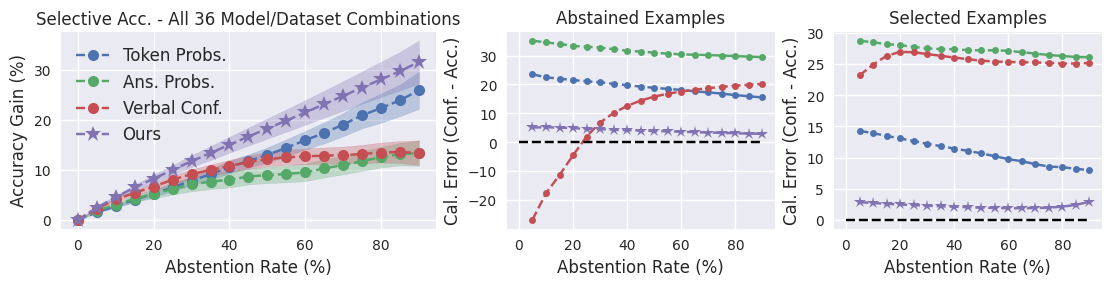

In [49]:
mean_df = full_df[["method", "rate", "sel_imp", "sel_acc", "sel_conf", "rej_conf", "rej_acc"]].groupby(["method", "rate"]).mean().reset_index()
std_df = full_df[["method", "rate", "sel_imp", "sel_acc", "sel_conf", "rej_conf", "rej_acc"]].groupby(["method", "rate"]).std().reset_index()

plot_title="All 36 Model/Dataset Combinations"

figsize=(11,2.75)

mosaic = [
    ["sel", "rej_cal", "sel_cal"],
    ["sel", "rej_cal", "sel_cal"],
]

fig, axd = plt.subplot_mosaic(
    mosaic, 
    figsize=figsize, 
    constrained_layout=True,
    width_ratios=[0.35, 0.25, 0.25]
)

methods = [
    "logprob", 
    "ans_logprob", 
    "vc", 
    OUR_METHOD
]

# --- Selective accuracy (big left plot) ---
ax = axd["sel"]
for i, method in enumerate(methods):
    method_df  = mean_df[mean_df["method"] == method].sort_values("rate")
    method_std = std_df[std_df["method"] == method].sort_values("rate")

    X, y = method_df["rate"].to_numpy(), method_df["sel_imp"].to_numpy()
    yerr = method_std["sel_imp"].to_numpy() / np.sqrt(len(models) * len(datasets))

    if method in METHODS_MAP:
        label = METHODS_MAP[method]
    else:
        label = method

    marker = "--o"
    s = 8
    if "nrt" in method:
        marker = "--*"
        s = 12

    ax.plot(X * 100, y * 100, marker, label=label, color=pal[i], markersize=s)
    ax.fill_between(X * 100, (y + yerr) * 100, (y - yerr) * 100, alpha=0.3, color=pal[i])

ax.set_xlabel("Abstention Rate (%)", fontsize=12)
ax.set_ylabel("Accuracy Gain (%)", fontsize=12)
if plot_title == "":
    ax.set_title(f"Selective Accuracy",  fontsize=12)
else:
    ax.set_title(f"Selective Acc. - {plot_title}",  fontsize=12)
ax.legend(fontsize=12)

# --- Right-side 2x2: confidence + accuracy of rejected examples ---
for i, method in enumerate(methods):

    ax = axd["rej_cal"]

    method_df = mean_df[mean_df["method"] == method].sort_values("rate")

    X = method_df["rate"].to_numpy()
    # ax.plot(X[1:] * 100, method_df["rej_conf"].to_numpy()[1:] * 100, "--o", label=METHODS_MAP[method], color=pal[i])
    # ax.plot(X[1:] * 100, method_df["rej_acc"].to_numpy()[1:]  * 100, "--",  label=METHODS_MAP[method],  color=pal[i])
    X = X[1:] * 100
    y = ((method_df["rej_conf"].to_numpy()) - (method_df["rej_acc"].to_numpy()))[1:]*100

    marker = "--o"
    s = 5
    if "nrt" in method:
        marker = "--*"
        s = 9

    ax.plot(X, y, marker,  label=METHODS_MAP[method],  color=pal[i], markersize=s)
    # ax.set_ylim(0, 100)

    # ax.set_title(METHODS_MAP[method], fontsize=12)
    if method not in ["logprob", "ans_logprob"]:
        ax.set_xlabel("Abstention Rate (%)",  fontsize=12)
        
    # ax.set_ylabel("Conf./Acc. (%)",  fontsize=11)
    # ax.legend(loc="lower right", fontsize=11)


axd["rej_cal"].plot([0, 90], [0, 0], "--", color="k")
axd["rej_cal"].set_title("Abstained Examples",  fontsize=12)
axd["rej_cal"].set_ylabel("Cal. Error (Conf. - Acc.)",  fontsize=12)

for i, method in enumerate(methods):

    ax = axd["sel_cal"]

    method_df = mean_df[mean_df["method"] == method].sort_values("rate")

    X = method_df["rate"].to_numpy()
    # ax.plot(X[1:] * 100, method_df["rej_conf"].to_numpy()[1:] * 100, "--o", label=METHODS_MAP[method], color=pal[i])
    # ax.plot(X[1:] * 100, method_df["rej_acc"].to_numpy()[1:]  * 100, "--",  label=METHODS_MAP[method],  color=pal[i])
    X = X[1:] * 100
    y = ((method_df["sel_conf"].to_numpy()) - (method_df["sel_acc"].to_numpy()))[1:]*100

    marker = "--o"
    s = 5
    if "nrt" in method:
        marker = "--*"
        s = 9

    ax.plot(X, y, marker,  label=METHODS_MAP[method],  color=pal[i], markersize=s)

    # ax.set_ylim(0, 100)

    # ax.set_title(METHODS_MAP[method], fontsize=12)
    if method not in ["logprob", "ans_logprob"]:
        ax.set_xlabel("Abstention Rate (%)",  fontsize=12)
    
    # ax.set_ylabel("Conf./Acc. (%)",  fontsize=11)
    # ax.legend(loc="lower right", fontsize=11)


axd["sel_cal"].plot([0, 90], [0, 0], "--", color="k")
axd["sel_cal"].set_title("Selected Examples",  fontsize=12)
axd["sel_cal"].set_ylabel("Cal. Error (Conf. - Acc.)",  fontsize=12)


plt.savefig("../plots/selection.png", dpi=600, bbox_inches="tight")
plt.show()


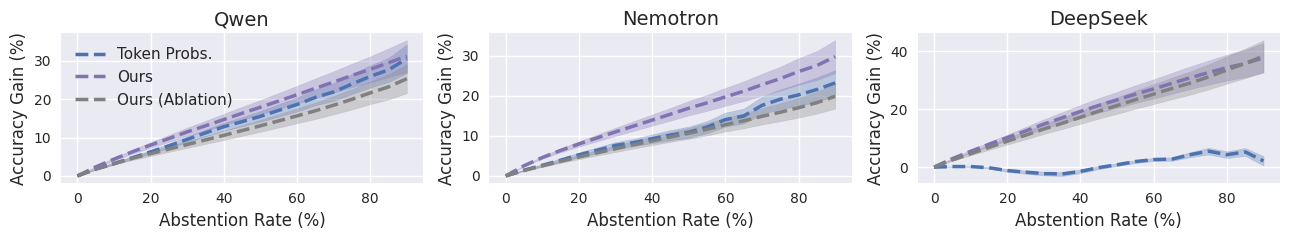

In [43]:
fig, axs = plt.subplots(1, len(model_fams), figsize=(13,2.5))

fam_idx = 0
for fam_name, fam_models in model_fams:
    
    ax = axs[fam_idx]
    
    sub_df = full_df[full_df["model"].isin(fam_models)]
    mean_df = sub_df[["method", "rate", "sel_imp", "rej_conf", "rej_acc"]].groupby(["method", "rate"]).mean().reset_index()
    std_df = sub_df[["method", "rate", "sel_imp", "rej_conf", "rej_acc"]].groupby(["method", "rate"]).std().reset_index()

    methods = ["logprob", "ans_logprob", "vc", OUR_METHOD, "ablation"]
    
    # --- Selective accuracy (big left plot) ---
    for i, method in enumerate(methods):

        if i in [1,2]:
            continue
        method_df  = mean_df[mean_df["method"] == method].sort_values("rate")
        method_std = std_df[std_df["method"] == method].sort_values("rate")
    
        X, y = method_df["rate"].to_numpy(), method_df["sel_imp"].to_numpy()
        yerr = method_std["sel_imp"].to_numpy() / np.sqrt(len(models) * len(datasets))

        # marker = "o"
        color = pal[i]
        if method == "ablation":
            # marker = "s"
            color = "grey"

        # marker = "--o"
        # s = 6
        # if "nrt" in method or method == "ablation":
        #     marker = "--*"
        #     s = 10
    
        ax.plot(X * 100, y * 100, "--", label=METHODS_MAP[method], color=color, lw=2.5)
        ax.fill_between(X * 100, (y + yerr) * 100, (y - yerr) * 100, alpha=0.3, color=color)
    
    ax.set_xlabel("Abstention Rate (%)", fontsize=12)
    ax.set_ylabel("Accuracy Gain (%)", fontsize=12)
    ax.set_title(f"{fam_name}", fontsize=14)
    if fam_idx == 0:
        ax.legend(fontsize=11)

    fam_idx += 1
    
fig.tight_layout()
plt.savefig("../plots/selection_by_family.png", dpi=600, bbox_inches="tight")
plt.show()

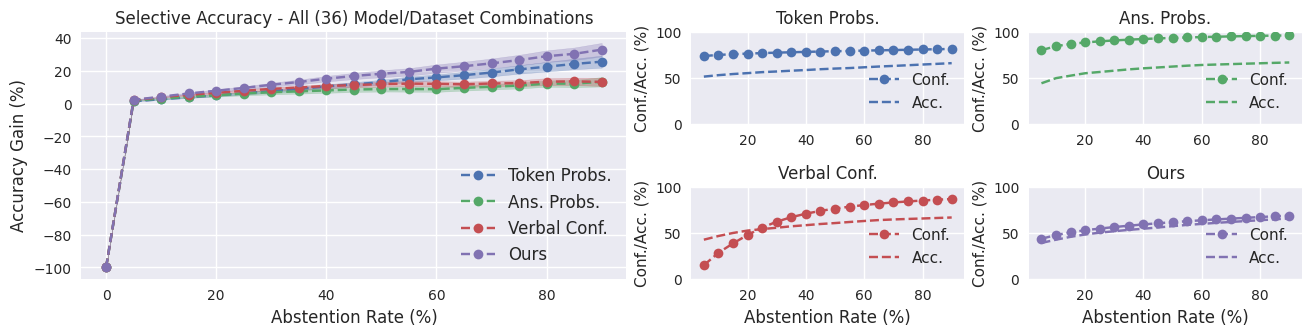

In [77]:
mean_df = full_df[["method", "rate", "sel_imp", "rej_conf", "rej_acc"]].groupby(["method", "rate"]).mean().reset_index()
std_df = full_df[["method", "rate", "sel_imp", "rej_conf", "rej_acc"]].groupby(["method", "rate"]).std().reset_index()

plot_title="All (36) Model/Dataset Combinations"

figsize=(13,3.25)

mosaic = [
    ["sel", "sel", "logprob", "ans_logprob"],
    ["sel", "sel", "vc", OUR_METHOD],
]

fig, axd = plt.subplot_mosaic(mosaic, figsize=figsize, constrained_layout=True)

methods = [
    "logprob", 
    "ans_logprob", 
    "vc", 
    OUR_METHOD
]

# --- Selective accuracy (big left plot) ---
ax = axd["sel"]
for i, method in enumerate(methods):
    method_df  = mean_df[mean_df["method"] == method].sort_values("rate")
    method_std = std_df[std_df["method"] == method].sort_values("rate")

    X, y = method_df["rate"].to_numpy(), method_df["sel_imp"].to_numpy()
    yerr = method_std["sel_imp"].to_numpy() / np.sqrt(len(models) * len(datasets))

    if method in METHODS_MAP:
        label = METHODS_MAP[method]
    else:
        label = method

    ax.plot(X * 100, y * 100, "--o", label=label, color=pal[i])
    ax.fill_between(X * 100, (y + yerr) * 100, (y - yerr) * 100, alpha=0.3, color=pal[i])

ax.set_xlabel("Abstention Rate (%)", fontsize=12)
ax.set_ylabel("Accuracy Gain (%)", fontsize=12)
if plot_title == "":
    ax.set_title(f"Selective Accuracy")
else:
    ax.set_title(f"Selective Accuracy - {plot_title}")
ax.legend(fontsize=12)

# --- Right-side 2x2: confidence + accuracy of rejected examples ---
for i, method in enumerate(methods):

    if method in axd:
        ax = axd[method]
    else:
        continue

    method_df = mean_df[mean_df["method"] == method].sort_values("rate")

    X = method_df["rate"].to_numpy()
    ax.plot(X[1:] * 100, method_df["rej_conf"].to_numpy()[1:] * 100, "--o", label="Conf.", color=pal[i])
    ax.plot(X[1:] * 100, method_df["rej_acc"].to_numpy()[1:]  * 100, "--",  label="Acc.",  color=pal[i])

    ax.set_ylim(0, 100)

    ax.set_title(METHODS_MAP[method], fontsize=12)
    if method not in ["logprob", "ans_logprob"]:
        ax.set_xlabel("Abstention Rate (%)",  fontsize=12)
    ax.set_ylabel("Conf./Acc. (%)",  fontsize=11)
    ax.legend(loc="lower right", fontsize=11)

# plt.savefig("../plots/selection.png", dpi=600, bbox_inches="tight")
plt.show()


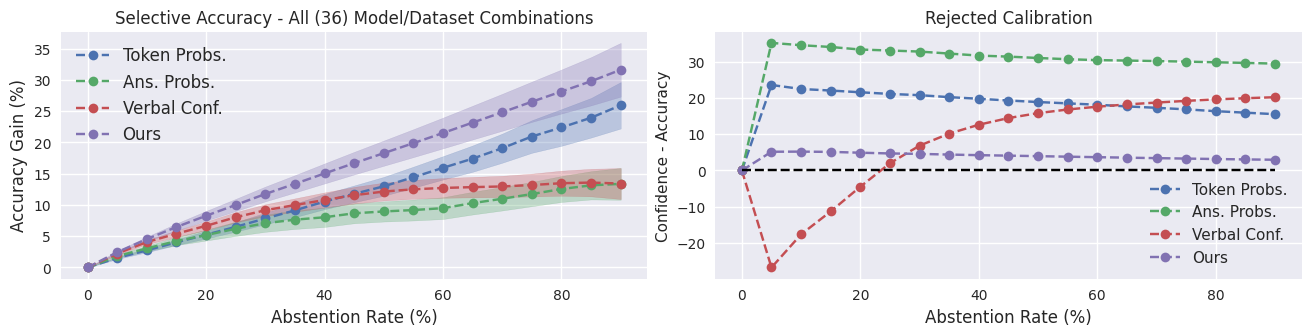

In [62]:
mean_df = full_df[["method", "rate", "sel_imp", "rej_conf", "rej_acc"]].groupby(["method", "rate"]).mean().reset_index()
std_df = full_df[["method", "rate", "sel_imp", "rej_conf", "rej_acc"]].groupby(["method", "rate"]).std().reset_index()

plot_title="All (36) Model/Dataset Combinations"

figsize=(13,3.25)

mosaic = [
    ["sel", "sel", "cal", "cal"],
    ["sel", "sel", "cal", "cal"],
]

fig, axd = plt.subplot_mosaic(mosaic, figsize=figsize, constrained_layout=True)

methods = [
    "logprob", 
    "ans_logprob", 
    "vc", 
    OUR_METHOD
]

# --- Selective accuracy (big left plot) ---
ax = axd["sel"]
for i, method in enumerate(methods):
    method_df  = mean_df[mean_df["method"] == method].sort_values("rate")
    method_std = std_df[std_df["method"] == method].sort_values("rate")

    X, y = method_df["rate"].to_numpy(), method_df["sel_imp"].to_numpy()
    yerr = method_std["sel_imp"].to_numpy() / np.sqrt(len(models) * len(datasets))

    if method in METHODS_MAP:
        label = METHODS_MAP[method]
    else:
        label = method

    ax.plot(X * 100, y * 100, "--o", label=label, color=pal[i])
    ax.fill_between(X * 100, (y + yerr) * 100, (y - yerr) * 100, alpha=0.3, color=pal[i])

ax.set_xlabel("Abstention Rate (%)", fontsize=12)
ax.set_ylabel("Accuracy Gain (%)", fontsize=12)
if plot_title == "":
    ax.set_title(f"Selective Accuracy")
else:
    ax.set_title(f"Selective Accuracy - {plot_title}")
ax.legend(fontsize=12)

# --- Right-side 2x2: confidence + accuracy of rejected examples ---
for i, method in enumerate(methods):

    ax = axd["cal"]

    method_df = mean_df[mean_df["method"] == method].sort_values("rate")

    X = method_df["rate"].to_numpy()
    # ax.plot(X[1:] * 100, method_df["rej_conf"].to_numpy()[1:] * 100, "--o", label=METHODS_MAP[method], color=pal[i])
    # ax.plot(X[1:] * 100, method_df["rej_acc"].to_numpy()[1:]  * 100, "--",  label=METHODS_MAP[method],  color=pal[i])
    X = X * 100
    y = ((method_df["rej_conf"].to_numpy()) - (method_df["rej_acc"].to_numpy()))*100
    ax.plot(X, y, "--o",  label=METHODS_MAP[method],  color=pal[i])

    # ax.set_ylim(0, 100)

    # ax.set_title(METHODS_MAP[method], fontsize=12)
    if method not in ["logprob", "ans_logprob"]:
        ax.set_xlabel("Abstention Rate (%)",  fontsize=12)
    ax.set_ylabel("Conf./Acc. (%)",  fontsize=11)
    ax.legend(loc="lower right", fontsize=11)


axd["cal"].plot([0, 90], [0, 0], "--", color="k")
axd["cal"].set_title("Rejected Calibration")
axd["cal"].set_ylabel("Confidence - Accuracy")


# plt.savefig("../plots/selection.png", dpi=600, bbox_inches="tight")
plt.show()
